注意事項
© [2026]. [Shin-ichi Ito]. 本ノートブックに含まれるオリジナルコードおよび内容の著作権は著者に帰属します。本ノートブックのダウンロードおよび改変は自由ですが、改変したコードを利用する際には、元の著者のクレジットを明記してください。また、本ノートブックを改変した場合は、その内容に関する責任は全て改変者に移ります。

In [1]:
# @title
# 必要なライブラリ
import sys
import subprocess
import importlib.util

package_name = "pytorch-optimizer"
module_name = "pytorch_optimizer"

if importlib.util.find_spec(module_name) is not None:
    print(f"✅ {package_name} is already installed.")
else:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", package_name],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )

    if result.returncode == 0:
        print(f"✅ Successfully installed {package_name}.")
    else:
        print(f"❌ Failed to install {package_name}.")
        print(result.stderr[-1000:])

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pytorch_optimizer import SOAP

torch.set_default_dtype(torch.float64)

# 乱数シード
np.random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


✅ pytorch-optimizer is already installed.


device(type='cuda')

# PINN演習：周期負荷下の1次元弾粘塑性モデル

このノートブックでは、正弦波ひずみ入力を受ける1次元弾粘塑性モデルを題材として、inverse PINN の基本的な実装を行う。


このノートブックの目的は、次の4点である。

1. 正弦波ひずみに対する応力–ひずみ履歴ループを確認する

2. 降伏しきい値による小振幅応答と大振幅応答の違いを確認する

3. 少数の応力観測から、応力と不可視な塑性ひずみをPINNにより推定する

4. 発展課題として、降伏応力を未知パラメータとして同時に推定する


## 1. モデル

プリンやゼリーのような柔らかい物体を小さく揺らすと、物体はプルプルと振動するだけで、揺れを止めればほぼ元の形に戻る。この範囲では、変形は主に弾性的であり、応答はおおむね可逆的である。

一方で、十分に強く揺らしたり押しつぶしたりすると、内部構造が崩れ、変形が完全には回復しなくなる。このように、あるしきい値を超えたときに不可逆な変形が進む現象は、降伏を伴う材料応答として理解できる。歯磨き粉、ペースト、泥、濃厚懸濁液なども、弱い応力ではほとんど流動せず、十分大きな応力を受けると流れ始める材料の例である。

本演習では、このような性質を表す単純な1次元弾粘塑性モデルを考える。入力として、周期的なひずみ

\begin{equation}
\varepsilon(t)=\varepsilon_0\sin(\omega t)
\end{equation}

を与える。ここで、$\varepsilon_0$ は入力ひずみの振幅、$\omega$ は角周波数である。ひずみ振幅が小さい場合には、材料はほぼ可逆的に応答する。一方で、ひずみ振幅が十分に大きい場合には、応力が降伏応力を超え、塑性変形が進行する。その結果、応力–ひずみ関係には履歴ループが現れる。

全ひずみを、弾性ひずみ $\varepsilon_e(t)$ と塑性ひずみ $\varepsilon_p(t)$ の和として

\begin{equation}
\varepsilon(t)=\varepsilon_e(t)+\varepsilon_p(t)
\end{equation}

と分解する。応力は弾性ひずみに比例すると仮定し、

\begin{equation}
\sigma(t)=E\varepsilon_e(t)
=E\{\varepsilon(t)-\varepsilon_p(t)\}
\end{equation}

で与える。ここで、$E$ は弾性率である。

塑性ひずみ速度については、Bingham型の降伏則

\begin{equation}
\dot{\varepsilon}_p
=
\frac{1}{\eta}
\max\left(|\sigma|-\sigma_y,0\right)\operatorname{sgn}(\sigma)
\end{equation}

を考える。ここで、$\eta$ は塑性粘度、$\sigma_y$ は降伏応力である。この式は、応力の大きさが降伏応力 $\sigma_y$ 以下のときには塑性変形が進まず、$\sigma_y$ を超えたときにのみ塑性流動が生じることを表している。

ただし、この厳密なBingham型の式には $\max$ 関数や $\operatorname{sgn}$ 関数が含まれており、降伏点近傍で微分可能性が悪い。そのため、勾配に基づく学習を行うPINN演習では、次の滑らか化した降伏則を用いる。

\begin{equation}
\dot{\varepsilon}_p
=
\frac{\sigma_{y}}{\eta}
\left[
\operatorname{softplus}_k\left(\frac{\sigma}{\sigma_{y}}-1\right)
-
\operatorname{softplus}_k\left(-\frac{\sigma}{\sigma_{y}}-1\right)
\right].
\end{equation}

ここで、

\begin{equation}
\operatorname{softplus}_k(x)
=
\frac{1}{k}\log\left(1+\exp(kx)\right)
\end{equation}

である。$k$ は滑らか化の強さを制御するパラメータであり、$k$ が大きいほど厳密なBingham型の降伏則に近づく。

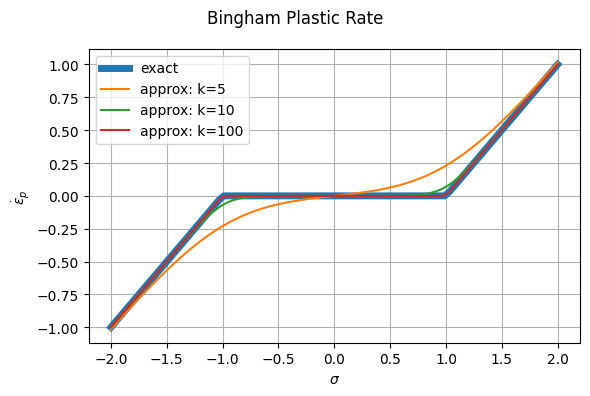

In [2]:
def softplus_smooth(x, k=50):
    # overflowを避ける安定版
    return np.logaddexp(0.0, k*x) / k

def plastic_rate_approx(sigma, eta=1, sigma_y=1, k=1):
    return (sigma_y / eta) * (softplus_smooth(sigma / sigma_y-1,k=k) - softplus_smooth(-sigma / sigma_y-1,k=k))

def plastic_rate_exact(sigma, eta=1, sigma_y=1):
    return np.maximum(np.abs(sigma)-sigma_y, 0) * np.sign(sigma)/ eta

sigma = np.linspace(-2,2,100)
plt.figure(figsize=(6, 4))
plt.plot(sigma, plastic_rate_exact(sigma), label="exact",lw=5)
plt.plot(sigma, plastic_rate_approx(sigma,k=3), label="approx: k=5")
plt.plot(sigma, plastic_rate_approx(sigma,k=10), label="approx: k=10")
plt.plot(sigma, plastic_rate_approx(sigma,k=100), label="approx: k=100")
plt.xlabel(r"$\sigma$")
plt.ylabel(r"$\dot{\varepsilon}_p$")
plt.legend()
plt.suptitle("Bingham Plastic Rate")
plt.tight_layout()
plt.grid()
plt.show()
plt.close()


## 2. 参照データの生成

まず、既知の材料パラメータを用いてモデル方程式を数値積分し、参照解を生成する。本演習では、この参照解を「実験データ」に相当するものとして扱う。すなわち、真の材料応答を数値的に作成し、その一部だけを観測データとしてPINNに与える。

降伏が生じるかどうかの目安は、降伏ひずみ

\begin{equation}
\varepsilon_y=\frac{\sigma_y}{E}
\end{equation}

で与えられる。これは、塑性ひずみがまだ生じていない状態で、応力が

\begin{equation}
\sigma=E\varepsilon
\end{equation}

により近似されることから得られる目安である。

入力振幅 $\varepsilon_0$ が $\varepsilon_y$ より十分小さい場合、応力は降伏応力に達しにくく、応答はほぼ弾性的になる。一方で、$\varepsilon_0$ が $\varepsilon_y$ を超える程度に大きい場合、周期負荷の途中で応力が降伏応力を超え、塑性ひずみが発生する。その結果、応力–ひずみ平面には履歴ループが現れる。

In [3]:
# 真の材料パラメータ
E_true = 10.0
eta_true = 1.0
sigma_y_true = 2.0

# 入力条件
omega = 1.0
eps0 = 0.50       # eps0 < sigma_y/E ならほぼ弾性、eps0 > sigma_y/E なら降伏しやすい

# 滑らか化パラメータ
k_smooth = 20.0

# 時間区間
T = 8 * np.pi       # 4周期
Nt = 1200
t_np = np.linspace(0.0, T, Nt)

def strain_np(t, eps0, omega=omega):
    return eps0 * np.sin(omega * t)

def softplus_np(x, k=k_smooth):
    # overflowを避ける安定版
    return np.logaddexp(0.0, k*x) / k

def plastic_rate_np(eps_p, t, eps0, E=E_true, eta=eta_true, sigma_y=sigma_y_true):
    eps = strain_np(t, eps0, omega)
    sigma = E * (eps - eps_p)
    return (sigma_y / eta) * (softplus_np(sigma / sigma_y-1) - softplus_np(-sigma / sigma_y-1))

def rk4_reference(t_grid,eps0):
    eps_p = np.zeros_like(t_grid)
    for n in range(len(t_grid)-1):
        t = t_grid[n]
        dt = t_grid[n+1] - t_grid[n]
        y = eps_p[n]
        k1 = plastic_rate_np(y, t, eps0)
        k2 = plastic_rate_np(y + 0.5*dt*k1, t + 0.5*dt, eps0)
        k3 = plastic_rate_np(y + 0.5*dt*k2, t + 0.5*dt, eps0)
        k4 = plastic_rate_np(y + dt*k3, t + dt, eps0)
        eps_p[n+1] = y + dt * (k1 + 2*k2 + 2*k3 + k4) / 6.0
    eps = strain_np(t_grid,eps0)
    sigma = E_true * (eps - eps_p)
    return eps, eps_p, sigma

eps_ref, epsp_ref, sigma_ref = rk4_reference(t_np, eps0)

print("yield strain sigma_y/E =", sigma_y_true / E_true)
print("input amplitude eps0   =", eps0)


yield strain sigma_y/E = 0.2
input amplitude eps0   = 0.5


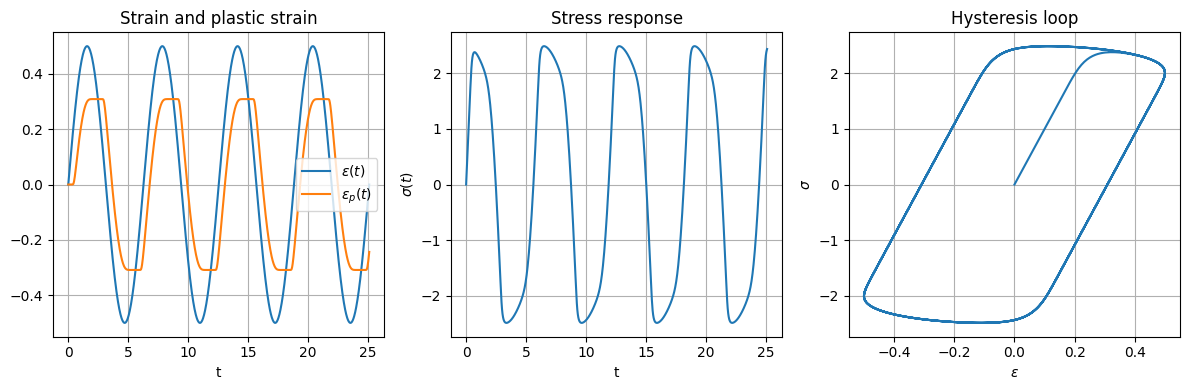

In [4]:
# 参照解の可視化
fig = plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(t_np, eps_ref, label=r"$\varepsilon(t)$")
plt.plot(t_np, epsp_ref, label=r"$\varepsilon_p(t)$")
plt.xlabel("t")
plt.legend()
plt.grid()
plt.title("Strain and plastic strain")

plt.subplot(1, 3, 2)
plt.plot(t_np, sigma_ref)
plt.xlabel("t")
plt.ylabel(r"$\sigma(t)$")
plt.title("Stress response")
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(eps_ref, sigma_ref)
plt.xlabel(r"$\varepsilon$")
plt.ylabel(r"$\sigma$")
plt.title("Hysteresis loop")
plt.grid()

plt.tight_layout()
plt.show()
plt.close()



## 3. 小振幅と大振幅の比較

次に、入力振幅の違いによって応答がどのように変化するかを確認する。同じ材料パラメータを用いた場合でも、入力振幅 $\varepsilon_0$ が降伏ひずみ $\varepsilon_y$ より十分小さいか、あるいはそれを超える程度に大きいかによって、応力–ひずみ応答は大きく異なる。

小振幅入力では、応力は降伏応力に達しにくく、応答はほぼ可逆的な弾性応答となる。一方で、大振幅入力では周期負荷の途中で降伏が生じ、塑性ひずみが蓄積する。その結果、応力–ひずみ平面には履歴ループが現れる。

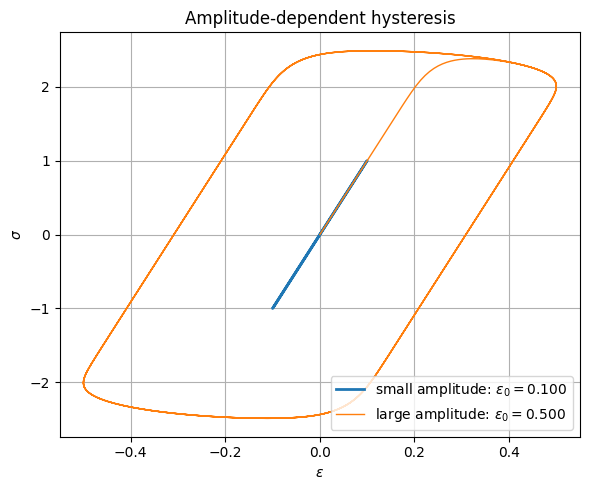

In [5]:
eps0_1 = 0.1
eps_small, epsp_small, sigma_small = rk4_reference(t_np, eps0=eps0_1)

eps0_2 = 0.5
eps_large, epsp_large, sigma_large = rk4_reference(t_np, eps0=eps0_2)

plt.figure(figsize=(6, 5))
plt.plot(eps_small, sigma_small, label=r"small amplitude: $\varepsilon_0=$"+"{:.3f}".format(eps0_1),lw=2)
plt.plot(eps_large, sigma_large, label=r"large amplitude: $\varepsilon_0=$"+"{:.3f}".format(eps0_2),lw=1)
plt.xlabel(r"$\varepsilon$")
plt.ylabel(r"$\sigma$")
plt.title("Amplitude-dependent hysteresis")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()
plt.close()




## 4. PINNの設定

ここからは、大振幅入力に対して得られた参照データを用いて、inverse PINN による状態推定を行う。ここでは、材料パラメータ $E,\eta,\sigma_y$ は既知とし、少数の応力観測から応力 $\sigma(t)$ と塑性ひずみ $\varepsilon_p(t)$ を再構成することを目的とする。

入力ひずみは既知とし、

\begin{equation}
\varepsilon(t)=\varepsilon_0\sin(\omega t)
\end{equation}

で与える。一方で、観測データとしてPINNに与えるのは、少数の時刻 $t_i$ における応力

\begin{equation}
\sigma(t_i)
\end{equation}

のみである。

ニューラルネットワークは、時刻 $t$ を入力として、応力と塑性ひずみ

\begin{equation}
\sigma_\theta(t), \quad \varepsilon_{p,\theta}(t)
\end{equation}

を出力する。ここで、添字 $\theta$ はニューラルネットワークの学習パラメータを表す。

PINNでは、観測データへの適合に加えて、モデル方程式を満たすことを損失関数に組み込む。本演習では、次の2つの残差を用いる。

\begin{equation}
\begin{aligned}
r_1(t)
&=
\sigma_\theta(t)-E\{\varepsilon(t)-\varepsilon_{p,\theta}(t)\},\\
r_2(t)
&=
\dfrac{d\varepsilon_{p,\theta}}{dt}
-
\frac{\sigma_{y}}{\eta}
\left[
\operatorname{softplus}_k\left(\frac{\sigma_\theta}{\sigma_{y}}-1\right)
-
\operatorname{softplus}_k\left(-\frac{\sigma_\theta}{\sigma_{y}}-1\right)
\right].
\end{aligned}
\end{equation}

第一の残差 $r_1$ は、応力が弾性ひずみに比例するという構成関係を表す。第二の残差 $r_2$ は、塑性ひずみの時間発展が滑らか化したBingham型の降伏則に従うことを表す。

最初の演習では、$E,\eta,\sigma_y$ を既知として扱い、状態変数 $\sigma(t)$ と $\varepsilon_p(t)$ の推定だけを行う。材料パラメータの同定は、後の発展課題として扱う。

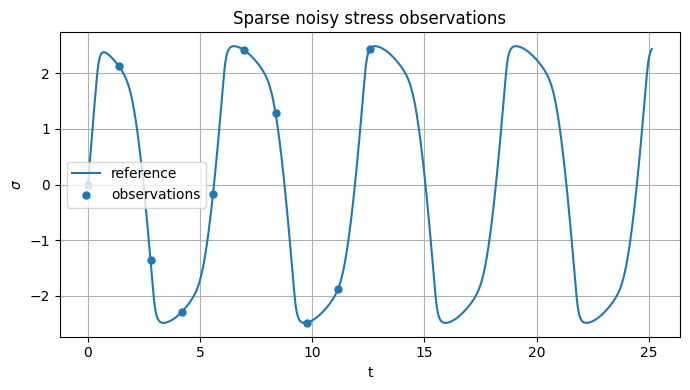

In [6]:
# 学習用データを準備
t_all = torch.tensor(t_np[:, None], device=device)
eps_all = torch.tensor(eps_ref[:, None], device=device)
sigma_all = torch.tensor(sigma_ref[:, None], device=device)
epsp_all = torch.tensor(epsp_ref[:, None], device=device)

# 少数の応力観測点
N_data = 10
idx_data = np.linspace(0, Nt//2-1, N_data).astype(int)

noise_level = 1e-5  # 応力ノイズの標準偏差
sigma_obs_np = sigma_ref[idx_data] + noise_level * np.std(sigma_ref) * np.random.randn(N_data)

t_data = torch.tensor(t_np[idx_data, None], device=device)
sigma_data = torch.tensor(sigma_obs_np[:, None], device=device)

plt.figure(figsize=(7, 4))
plt.plot(t_np, sigma_ref, label="reference")
plt.scatter(t_np[idx_data], sigma_obs_np, s=25, label="observations")
plt.xlabel("t")
plt.ylabel(r"$\sigma$")
plt.title("Sparse noisy stress observations")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()
plt.close()



In [7]:
# 正弦波ひずみをtorchで定義
def strain_torch(t):
    return eps0 * torch.sin(omega * t)

def softplus_torch(x):
    return torch.nn.functional.softplus(k_smooth * x) / k_smooth

def bingham_rate_torch(sigma, eta=eta_true, sigma_y=sigma_y_true):
    return sigma_y / eta * (softplus_torch(sigma/sigma_y-1)-softplus_torch(-sigma/sigma_y-1))

class MLP(nn.Module):
    def __init__(self, width=32, depth=3):
        super().__init__()
        layers = []
        layers.append(nn.Linear(1, width))
        layers.append(nn.Tanh())
        for _ in range(depth-1):
            layers.append(nn.Linear(width, width))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(width, 2))  # output: sigma, eps_p
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        # 入力を [-1, 1] 程度にスケーリング
        x = 2.0 * t / T - 1.0
        return self.net(x)

def pinn_residuals(model, t_col):
    t_col = t_col.clone().detach().requires_grad_(True)
    out = model(t_col)
    sigma = out[:, 0:1]
    eps_p = out[:, 1:2]

    depsp_dt = torch.autograd.grad(
        eps_p, t_col,
        grad_outputs=torch.ones_like(eps_p),
        create_graph=True
    )[0]

    eps = strain_torch(t_col)

    r_constitutive = sigma - E_true * (eps - eps_p)
    r_flow = depsp_dt - bingham_rate_torch(sigma)

    return r_constitutive, r_flow, sigma, eps_p


## 5. PINN学習

次に、定義した損失関数を最小化し、ニューラルネットワークのパラメータを学習する。物理残差を評価する collocation 点には、時間区間内からランダムにサンプリングした点を用いる。

学習では、少数の応力観測に対するデータ損失と、モデル方程式に対応する物理残差損失を同時に最小化する。これにより、観測点だけに過度に依存するのではなく、時間区間全体で構成則と塑性発展則を満たすような解を求める。

実行時間が長い場合は、`n_iter` を小さくするとよい。一方で、より高い精度を得たい場合は、`n_iter` や collocation 点数 `N_col` を増やすことで、学習反復回数や物理残差を評価する点数を増やすことができる。

In [8]:

model = MLP(width=64, depth=4).to(device)
optimizer = SOAP(model.parameters(),lr=1e-3)

N_col = 2000
n_iter = 30000

w_data = 1.0
w_const = 1.0
w_flow = 10.0
w_init = 10.0

history = []

for it in range(1, n_iter + 1):
    optimizer.zero_grad()

    # データ損失
    sigma_pred_data = model(t_data)[:, 0:1]
    loss_data = torch.mean((sigma_pred_data - sigma_data)**2)


    # 物理損失
    t_col = torch.rand(N_col,device=device).reshape(-1,1) * T
    r1, r2, _, _ = pinn_residuals(model, t_col)
    loss_const = torch.mean(r1**2)
    loss_flow = torch.mean(r2**2)

    # 初期塑性ひずみ eps_p(0)=0
    epsp0 = model(torch.zeros((1, 1), device=device))[:, 1:2]
    loss_init = torch.mean(epsp0**2)

    loss = (
        w_data * loss_data
        + w_const * loss_const
        + w_flow * loss_flow
        + w_init * loss_init
    )

    loss.backward()
    optimizer.step()

    if it % 500 == 0 or it == 1:
        history.append([it, loss.item(), loss_data.item(), loss_const.item(), loss_flow.item(), loss_init.item()])
        print(f"it={it:5d} loss={loss.item():.3e} data={loss_data.item():.3e} const={loss_const.item():.3e} flow={loss_flow.item():.3e}")

history = np.array(history)


it=    1 loss=1.580e+01 data=3.467e+00 const=1.233e+01 flow=7.242e-06
it=  500 loss=1.398e+01 data=3.324e+00 const=1.059e+01 flow=1.449e-03
it= 1000 loss=3.059e+00 data=1.330e+00 const=1.360e+00 flow=3.692e-02
it= 1500 loss=1.898e-01 data=5.582e-03 const=2.299e-02 flow=1.610e-02
it= 2000 loss=1.134e-02 data=1.651e-04 const=3.239e-03 flow=7.929e-04
it= 2500 loss=5.302e-03 data=1.399e-04 const=1.947e-03 flow=3.211e-04
it= 3000 loss=2.742e-03 data=7.034e-05 const=1.183e-03 flow=1.472e-04
it= 3500 loss=2.098e-03 data=6.616e-05 const=8.807e-04 flow=1.135e-04
it= 4000 loss=1.614e-03 data=8.548e-05 const=6.211e-04 flow=9.057e-05
it= 4500 loss=1.276e-03 data=2.272e-05 const=5.164e-04 flow=6.978e-05
it= 5000 loss=1.108e-03 data=3.678e-05 const=4.641e-04 flow=5.988e-05
it= 5500 loss=8.782e-04 data=4.205e-05 const=2.963e-04 flow=5.382e-05
it= 6000 loss=7.897e-04 data=3.917e-05 const=3.027e-04 flow=4.460e-05
it= 6500 loss=5.889e-04 data=8.442e-06 const=2.259e-04 flow=3.252e-05
it= 7000 loss=4.812e

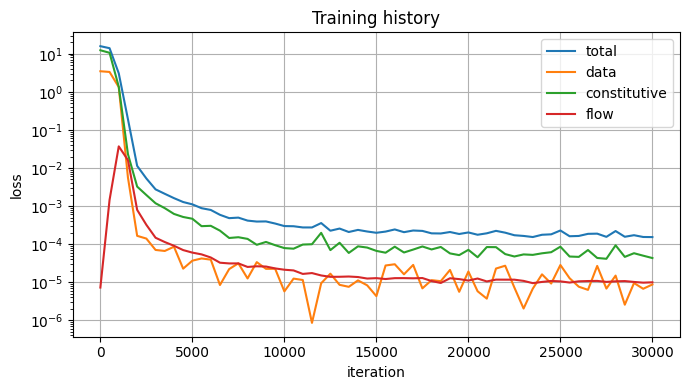

In [9]:
# 学習曲線
plt.figure(figsize=(7, 4))
plt.semilogy(history[:, 0], history[:, 1], label="total")
plt.semilogy(history[:, 0], history[:, 2], label="data")
plt.semilogy(history[:, 0], history[:, 3], label="constitutive")
plt.semilogy(history[:, 0], history[:, 4], label="flow")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.title("Training history")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()
plt.close()



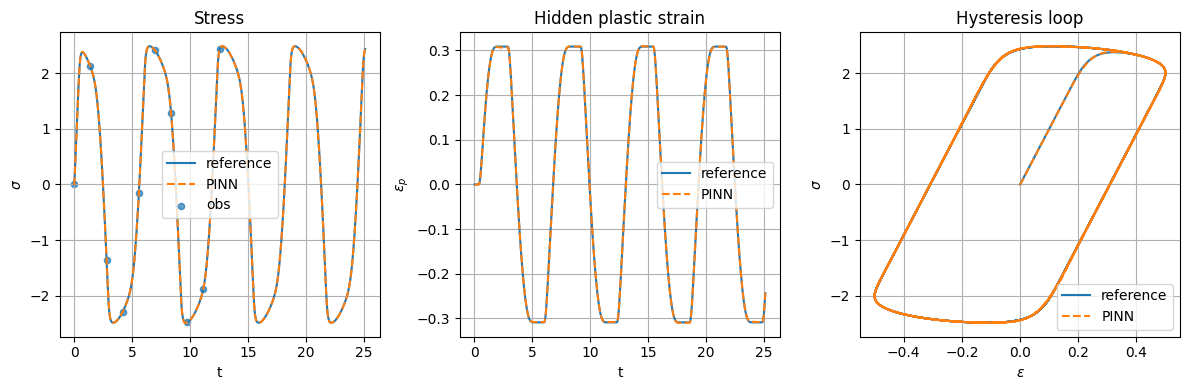

RMSE sigma = 0.005775980943375192
RMSE eps_p = 0.0008145790022252132


In [10]:
# PINN予測を評価
model.eval()
with torch.no_grad():
    pred = model(t_all)
    sigma_pinn = pred[:, 0].cpu().numpy()
    epsp_pinn = pred[:, 1].cpu().numpy()
    eps_np = eps_ref

fig = plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(t_np, sigma_ref, label="reference")
plt.plot(t_np, sigma_pinn, "--", label="PINN")
plt.scatter(t_np[idx_data], sigma_obs_np, s=20, alpha=0.7, label="obs")
plt.xlabel("t")
plt.ylabel(r"$\sigma$")
plt.title("Stress")
plt.legend()
plt.grid()


plt.subplot(1, 3, 2)
plt.plot(t_np, epsp_ref, label="reference")
plt.plot(t_np, epsp_pinn, "--", label="PINN")
plt.xlabel("t")
plt.ylabel(r"$\varepsilon_p$")
plt.title("Hidden plastic strain")
plt.legend()
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(eps_ref, sigma_ref, label="reference")
plt.plot(eps_ref, sigma_pinn, "--", label="PINN")
plt.xlabel(r"$\varepsilon$")
plt.ylabel(r"$\sigma$")
plt.title("Hysteresis loop")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()
plt.close()

rmse_sigma = np.sqrt(np.mean((sigma_pinn - sigma_ref)**2))
rmse_epsp = np.sqrt(np.mean((epsp_pinn - epsp_ref)**2))
print("RMSE sigma =", rmse_sigma)
print("RMSE eps_p =", rmse_epsp)


## 6. 比較：通常のNN回帰

最後に、同じ少数観測データに対して、物理残差を用いない通常のニューラルネットワーク回帰を行う。ここでは、時刻 $t$ を入力として応力 $\sigma(t)$ を直接回帰する。

PINNとの主な違いは、通常のNN回帰ではモデル方程式を損失関数に含めない点である。そのため、観測点近傍では応力データに適合できても、未観測領域で構成則や塑性発展則を満たすとは限らない。

この比較では、次の点に注目する。

- 観測点の間や外側で、応力応答を自然に補間・外挿できるか
- 応力–ひずみ平面の履歴ループを再現できるか
- 物理モデルに含まれる内部変数を推定できるか

通常のNN回帰は $\sigma(t)$ のみを直接学習するため、塑性ひずみ $\varepsilon_p(t)$ は得られない。一方で、PINNでは構成則と発展則を同時に用いるため、観測されていない内部変数 $\varepsilon_p(t)$ も推定対象として扱うことができる。

it=    1 loss=3.469e+00
it=  500 loss=3.196e+00
it= 1000 loss=9.834e-01
it= 1500 loss=5.340e-06
it= 2000 loss=2.921e-06
it= 2500 loss=1.832e-06
it= 3000 loss=1.194e-06
it= 3500 loss=3.044e-06
it= 4000 loss=8.897e-07
it= 4500 loss=4.024e-07
it= 5000 loss=1.850e-06
it= 5500 loss=1.949e-06
it= 6000 loss=4.484e-06
it= 6500 loss=7.676e-07
it= 7000 loss=9.586e-07
it= 7500 loss=8.195e-07
it= 8000 loss=1.365e-06
it= 8500 loss=7.631e-07
it= 9000 loss=7.839e-07
it= 9500 loss=1.227e-06
it=10000 loss=9.188e-07
it=10500 loss=1.187e-06
it=11000 loss=6.804e-07
it=11500 loss=2.937e-06
it=12000 loss=7.324e-07
it=12500 loss=1.146e-06
it=13000 loss=1.033e-06
it=13500 loss=4.566e-07
it=14000 loss=1.194e-06
it=14500 loss=5.001e-07
it=15000 loss=8.078e-07
it=15500 loss=7.043e-07
it=16000 loss=9.661e-07
it=16500 loss=1.316e-06
it=17000 loss=3.915e-07
it=17500 loss=1.631e-07
it=18000 loss=8.353e-07
it=18500 loss=1.709e-06
it=19000 loss=8.996e-07
it=19500 loss=6.903e-07
it=20000 loss=2.296e-07
it=20500 loss=4.

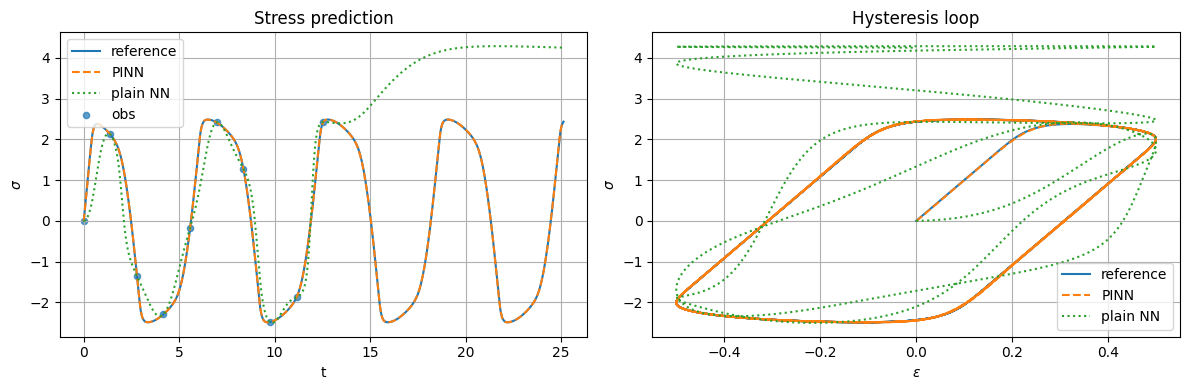

RMSE plain NN sigma = 3.1148150351694723
RMSE PINN sigma     = 0.005775980943375192


In [11]:
class ScalarMLP(nn.Module):
    def __init__(self, width=32, depth=3):
        super().__init__()
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth-1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, t):
        x = 2.0 * t / T - 1.0
        return self.net(x)

reg_model = ScalarMLP(width=64, depth=4).to(device)
reg_opt = SOAP(reg_model.parameters(), lr=1e-3)

n_iter = 30000

for it in range(1, n_iter + 1):
    reg_opt.zero_grad()
    pred = reg_model(t_data)
    loss = torch.mean((pred - sigma_data)**2)
    loss.backward()
    reg_opt.step()
    if it % 500 == 0 or it == 1:
        print(f"it={it:5d} loss={loss.item():.3e}")

with torch.no_grad():
    sigma_reg = reg_model(t_all).cpu().numpy().ravel()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(t_np, sigma_ref, label="reference")
plt.plot(t_np, sigma_pinn, "--", label="PINN")
plt.plot(t_np, sigma_reg, ":", label="plain NN")
plt.scatter(t_np[idx_data], sigma_obs_np, s=20, alpha=0.7, label="obs")
plt.xlabel("t")
plt.ylabel(r"$\sigma$")
plt.title("Stress prediction")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(eps_ref, sigma_ref, label="reference")
plt.plot(eps_ref, sigma_pinn, "--", label="PINN")
plt.plot(eps_ref, sigma_reg, ":", label="plain NN")
plt.xlabel(r"$\varepsilon$")
plt.ylabel(r"$\sigma$")
plt.title("Hysteresis loop")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

print("RMSE plain NN sigma =", np.sqrt(np.mean((sigma_reg - sigma_ref)**2)))
print("RMSE PINN sigma     =", np.sqrt(np.mean((sigma_pinn - sigma_ref)**2)))


## 7. 発展：降伏応力 $\sigma_y$ の同時推定

ここまでは、材料パラメータ $E,\eta,\sigma_y$ を既知として扱い、応力 $\sigma(t)$ と塑性ひずみ $\varepsilon_p(t)$ の状態推定を行った。ここでは発展課題として、弾性率 $E$ と塑性粘度 $\eta$ は既知とし、降伏応力 $\sigma_y$ のみを未知パラメータとして同時に推定する。

降伏応力は正の値をとる必要があるため、学習パラメータ $q$ を用いて

\begin{equation}
\sigma_y = \operatorname{softplus}(q)
\end{equation}

とパラメータ化する。このように書くことで、最適化の途中でも $\sigma_y>0$ が保たれる。

この設定では、ニューラルネットワークによる状態推定と、材料パラメータ $\sigma_y$ の同定を同時に行う。すなわち、少数の応力観測と物理残差を用いて、観測されていない塑性ひずみだけでなく、降伏を特徴づける材料パラメータも推定する。

In [12]:
class InversePINN(nn.Module):
    def __init__(self, width=32, depth=3, sigma_y_init=1.0):
        super().__init__()
        self.state_net = MLP(width=width, depth=depth)
        # softplus(q) が sigma_y_init 付近になるように初期化
        q0 = np.log(np.exp(sigma_y_init) - 1.0)
        self.q_sigma_y = nn.Parameter(torch.tensor(q0, device=device))

    def sigma_y(self):
        return torch.nn.functional.softplus(self.q_sigma_y)

    def forward(self, t):
        return self.state_net(t)

def inverse_residuals(model, t_col):
    t_col = t_col.clone().detach().requires_grad_(True)
    out = model(t_col)
    sigma = out[:, 0:1]
    eps_p = out[:, 1:2]

    depsp_dt = torch.autograd.grad(
        eps_p, t_col,
        grad_outputs=torch.ones_like(eps_p),
        create_graph=True
    )[0]

    eps = strain_torch(t_col)
    sigma_y = model.sigma_y()

    r_constitutive = sigma - E_true * (eps - eps_p)
    rate = sigma_y/ eta_true * (softplus_torch(sigma/sigma_y-1)-softplus_torch(-sigma/sigma_y-1))
    r_flow = depsp_dt - rate
    return r_constitutive, r_flow, sigma, eps_p

inv_model = InversePINN(width=64, depth=4, sigma_y_init=1.0).to(device)
inv_opt = SOAP(inv_model.parameters(), lr=1e-3)

n_iter = 30000

history_inv = []
for it in range(1, n_iter + 1):
    inv_opt.zero_grad()

    sigma_pred_data = inv_model(t_data)[:, 0:1]
    loss_data = torch.mean((sigma_pred_data - sigma_data)**2)

    t_col = torch.rand(N_col,device=device).reshape(-1,1) * T
    r1, r2, _, _ = inverse_residuals(inv_model, t_col)
    loss_const = torch.mean(r1**2)
    loss_flow = torch.mean(r2**2)

    epsp0 = inv_model(torch.zeros((1, 1), device=device))[:, 1:2]
    loss_init = torch.mean(epsp0**2)

    loss = (
        w_data * loss_data
        + w_const * loss_const
        + w_flow * loss_flow
        + w_init * loss_init
    )

    loss.backward()
    inv_opt.step()

    if it % 500 == 0 or it == 1:
        sy = inv_model.sigma_y().item()
        history_inv.append([it, loss.item(), sy])
        print(f"it={it:5d} loss={loss.item():.3e} data={loss_data.item():.3e} const={loss_const.item():.3e} flow={loss_flow.item():.3e} sigma_y={sy:.4f}")

history_inv = np.array(history_inv)


it=    1 loss=1.637e+01 data=3.467e+00 const=1.290e+01 flow=1.275e-06 sigma_y=1.0000
it=  500 loss=1.388e+01 data=3.376e+00 const=1.042e+01 flow=2.246e-03 sigma_y=1.1788
it= 1000 loss=2.594e+00 data=1.388e+00 const=7.789e-01 flow=4.256e-02 sigma_y=1.2802
it= 1500 loss=2.271e-01 data=4.176e-02 const=3.263e-02 flow=1.522e-02 sigma_y=1.6480
it= 2000 loss=1.040e-02 data=1.316e-04 const=2.777e-03 flow=7.487e-04 sigma_y=1.9915
it= 2500 loss=4.814e-03 data=6.138e-05 const=1.151e-03 flow=3.592e-04 sigma_y=2.0084
it= 3000 loss=2.961e-03 data=4.117e-05 const=1.022e-03 flow=1.878e-04 sigma_y=2.0118
it= 3500 loss=2.210e-03 data=4.407e-05 const=8.943e-04 flow=1.261e-04 sigma_y=2.0061
it= 4000 loss=1.565e-03 data=4.117e-05 const=5.301e-04 flow=9.874e-05 sigma_y=2.0045
it= 4500 loss=1.339e-03 data=3.020e-05 const=4.851e-04 flow=8.161e-05 sigma_y=2.0035
it= 5000 loss=1.067e-03 data=4.286e-05 const=2.996e-04 flow=6.800e-05 sigma_y=2.0026
it= 5500 loss=1.000e-03 data=2.865e-05 const=3.716e-04 flow=5.999

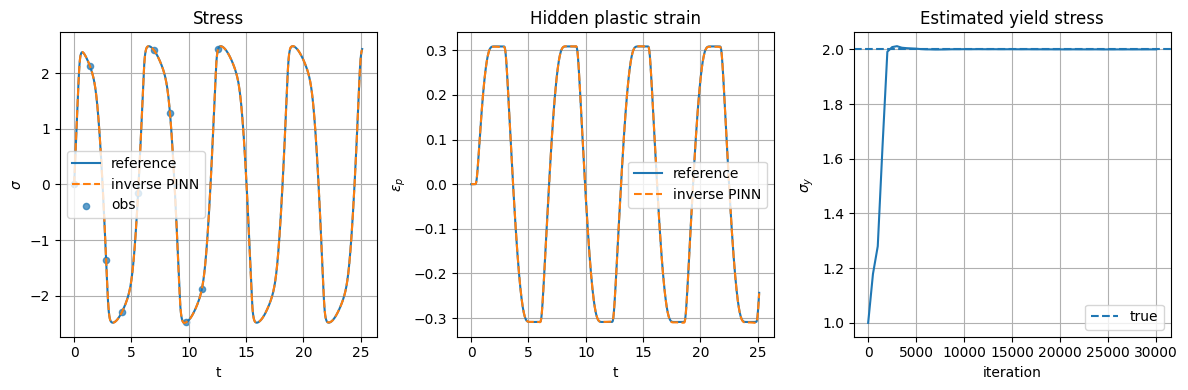

true sigma_y     = 2.0
estimated sigma_y= 2.0000412437527055
RMSE sigma       = 0.006335000583800563
RMSE eps_p       = 0.0007036455922171405


In [13]:
# 逆問題の結果
inv_model.eval()
with torch.no_grad():
    pred = inv_model(t_all)
    sigma_inv = pred[:, 0].cpu().numpy()
    epsp_inv = pred[:, 1].cpu().numpy()
    sigma_y_est = inv_model.sigma_y().item()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(t_np, sigma_ref, label="reference")
plt.plot(t_np, sigma_inv, "--", label="inverse PINN")
plt.scatter(t_np[idx_data], sigma_obs_np, s=20, alpha=0.7, label="obs")
plt.xlabel("t")
plt.ylabel(r"$\sigma$")
plt.title("Stress")
plt.legend()
plt.grid()

plt.subplot(1, 3, 2)
plt.plot(t_np, epsp_ref, label="reference")
plt.plot(t_np, epsp_inv, "--", label="inverse PINN")
plt.xlabel("t")
plt.ylabel(r"$\varepsilon_p$")
plt.title("Hidden plastic strain")
plt.legend()
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(history_inv[:, 0], history_inv[:, 2])
plt.axhline(sigma_y_true, linestyle="--", label="true")
plt.xlabel("iteration")
plt.ylabel(r"$\sigma_y$")
plt.title("Estimated yield stress")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

print("true sigma_y     =", sigma_y_true)
print("estimated sigma_y=", sigma_y_est)
print("RMSE sigma       =", np.sqrt(np.mean((sigma_inv - sigma_ref)**2)))
print("RMSE eps_p       =", np.sqrt(np.mean((epsp_inv - epsp_ref)**2)))


## 8. 演習課題案

### 課題1：入力振幅を変える

入力振幅 `eps0` を変化させ、応力–ひずみ平面に現れる履歴ループがどのように変化するかを確認する。

特に、降伏ひずみの目安である

\begin{equation}
\varepsilon_y=\frac{\sigma_y}{E}
\end{equation}

に対して、

\begin{equation}
\varepsilon_0 < \varepsilon_y
\end{equation}

の場合と、

\begin{equation}
\varepsilon_0 > \varepsilon_y
\end{equation}

の場合を比較する。小振幅入力ではほぼ可逆的な応答が得られる一方で、大振幅入力では塑性ひずみが発生し、履歴ループが現れることを確認する。

### 課題2：観測点数を減らす

観測点数 `N_data` を 40, 20, 10 などに変化させ、PINNと通常のNN回帰の結果を比較する。

観測点数が少なくなると、通常のNN回帰では観測点の間の補間や履歴ループの再現が難しくなる場合がある。一方で、PINNでは物理残差を用いるため、少数観測でも構成則と発展則に整合する解が得られるかを確認する。

### 課題3：ノイズを増やす

観測データに加えるノイズの大きさ `noise_level` を変化させ、PINNの推定結果がどの程度頑健であるかを確認する。

ノイズが大きくなると、観測データだけに基づく回帰は不安定になりやすい。物理残差を加えることで、応力や塑性ひずみの推定がどの程度安定化されるかを比較する。

### 課題4：滑らか化パラメータを変える

滑らか化パラメータ `k_smooth` を変化させ、降伏則の滑らかさが結果に与える影響を確認する。

`k_smooth` を大きくすると、滑らか化した降伏則は厳密なBingham型の降伏則に近づく。一方で、降伏点近傍の変化が急峻になり、PINNの学習が難しくなる可能性がある。非滑らかな構成則が、勾配に基づく学習にとってなぜ難しいかを考察する。

### 課題5：未知パラメータを増やす

発展課題として、降伏応力 $\sigma_y$ だけでなく、弾性率 $E$ や塑性粘度 $\eta$ も未知パラメータとして同時に推定する。

複数の材料パラメータを同時に推定する場合、観測点数が少ないとパラメータの同定性が悪くなる可能性がある。観測点数、ノイズの大きさ、入力振幅を変えながら、どの条件で安定したパラメータ推定が可能になるかを確認する。